<img src="../../../docs/assets/0.-BC-dev-hub-LOGO-flicker.svg" alt="BrainChip Dev Hub" width="200"/>

# Visual Wake Words on Akida 1

<p align="right">
Run Time: ~1 hour with training included / ~2 minutes with training skipped
</p>

This notebook steps through the full pipeline for a **Visual Wake Words (VWW)**
binary classifier on **Akida 1 (AKD1500)**: training a tf_keras model,
quantization and conversion to Akida format, and evaluation of the resulting
Akida model. For background on the VWW task, dataset, and model performance
benchmarks, see the [README](README.md).

The focus is on the **Akida-specific** aspects of the pipeline. The full data
preprocessing and training code is available in the accompanying Python files —
it is standard tf_keras code and is not described further in this notebook.

By default, model training is run to ensure reproducibility. However, you can
cut the running time of the notebook to under a minute if desired by 
skipping the training runs and downloading pretrained float and quantized models
instead: simply set the relevant `RUN_FLOAT_TRAINING` and `RUN_QAT_TRAINING`
variables in the first code cell to `False`.

## Setup

The default dataset path is `./data/vw_coco2014_96`. See the [README](README.md)
for download instructions and symlink setup. Update `DATA_PATH` below if needed.

In [14]:
import os
import pooch

import numpy as np
from tf_keras.utils import set_random_seed

In [2]:
DATA_PATH = './data/vw_coco2014_96'
MODELS_DIR = './models'
os.makedirs(MODELS_DIR, exist_ok=True)

RUN_FLOAT_TRAINING = True
RUN_QAT_TRAINING = True

SEED = 42

set_random_seed(SEED)

## Dataset

`get_data` returns a training and a validation `tf.data.Dataset`. The full
preprocessing and augmentation code is in [vww_data.py](vww_data.py) —
standard tf_keras pipeline code, not described further here.

In [3]:
from vww_data import get_data

BATCH_SIZE = 32
INPUT_SHAPE = (96, 96, 3)

train_ds, val_ds = get_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE)

Found 98658 images belonging to 2 classes.
Found 10961 images belonging to 2 classes.


I0000 00:00:1781174085.998956    9402 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22428 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:04:00.0, compute capability: 8.6


## Model

The backbone is **AkidaNet** — a MobileNet V1 variant whose layer structure
maps efficiently onto Akida hardware — with width multiplier `alpha=0.25`.
The narrow variant keeps parameter count low while retaining sufficient
capacity for the binary VWW task.

Key design choices:

- **Input resolution 96×96**, down from the 224×224 used for the ImageNet
  base model.
- **2-class output head** (person / non-person), returning raw logits — no
  softmax. The loss function handles the softmax implicitly via
  `from_logits=True`.
- **`input_scaling=(255, 0)`** embeds a linear mapping from uint8 [0, 255]
  to float [0, 1] as the first layer. This keeps the data pipeline
  hardware-friendly — inputs never need to be normalised outside the model.
- **`AkidaVersion.v1` context** constrains the layer configuration to what
  the AKD1500 hardware supports.

In [4]:
from akida_models import akidanet_imagenet
from cnn2snn import set_akida_version, AkidaVersion

with set_akida_version(AkidaVersion.v1):
    model = akidanet_imagenet(
        input_shape=INPUT_SHAPE,
        classes=2,
        alpha=0.25,
        include_top=True,
        input_scaling=(255, 0),
    )

model.summary()

2026-06-11 12:34:46.480962330 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


Model: "akidanet_0.25_96_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 96, 96, 3)]       0         
                                                                 
 rescaling (Rescaling)       (None, 96, 96, 3)         0         
                                                                 
 conv_0 (Conv2D)             (None, 48, 48, 8)         216       
                                                                 
 conv_0/BN (BatchNormalizat  (None, 48, 48, 8)         32        
 ion)                                                            
                                                                 
 conv_0/relu (ReLU)          (None, 48, 48, 8)         0         
                                                                 
 conv_1 (Conv2D)             (None, 48, 48, 16)        1152      
                                                

## Float Training

The model is trained for 50 epochs using Adam with a step-decay learning rate
schedule. The full training code is in [vww_train.py](vww_train.py) —
standard tf_keras code, not described further here.


In [5]:
from vww_train import train_vww


if RUN_FLOAT_TRAINING:
    LEARNING_RATE = 1e-3
    EPOCHS = 50

    train_vww(model, train_ds, val_ds,
            EPOCHS,
            LEARNING_RATE,
            )

    float_model_path = os.path.join(MODELS_DIR, 'akidanet_vww.h5')
    model.save(float_model_path, include_optimizer=False)
    print(f'Float model saved to {float_model_path}')
else:
    from tf_keras.models import load_model
    print('Training skipped. Retreiving model from BrainChip server...')
    model_url = 'https://data.brainchip.com/models/AkidaV1/akidanet/akidanet_vww.h5'
    model_path = pooch.retrieve(
            url=model_url,
            known_hash='00e03f13226cd622ad92bdb3402c4b4399a69875f2dde6ccadfb235ad6994d78',
            path="./models",
            fname='pretrained_' + os.path.basename(model_url),
        )
    model = load_model(model_path)

Best model saved as /tmp/tmpa3ymm38x/best_model.h5.
Epoch 1/50


I0000 00:00:1781174088.196029    9591 cuda_dnn.cc:529] Loaded cuDNN version 90300


3084/3084 [==============================] - 124s 40ms/step - loss: 0.6550 - accuracy: 0.6703 - val_loss: 0.6279 - val_accuracy: 0.6935 - lr: 0.0010
Epoch 2/50
   1/3084 [..............................] - ETA: 2:29 - loss: 0.5571 - accuracy: 0.7812

/home/dmclelland/miniconda3/envs/ak2191/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3084/3084 [==============================] - 119s 39ms/step - loss: 0.5641 - accuracy: 0.7374 - val_loss: 0.5885 - val_accuracy: 0.7148 - lr: 0.0010
Epoch 3/50
3084/3084 [==============================] - 117s 38ms/step - loss: 0.5128 - accuracy: 0.7654 - val_loss: 0.5012 - val_accuracy: 0.7754 - lr: 0.0010
Epoch 4/50
3084/3084 [==============================] - 122s 39ms/step - loss: 0.4860 - accuracy: 0.7824 - val_loss: 0.4756 - val_accuracy: 0.7904 - lr: 0.0010
Epoch 5/50
3084/3084 [==============================] - 121s 39ms/step - loss: 0.4709 - accuracy: 0.7893 - val_loss: 0.4961 - val_accuracy: 0.7813 - lr: 0.0010
Epoch 6/50
3084/3084 [==============================] - 120s 39ms/step - loss: 0.4571 - accuracy: 0.7978 - val_loss: 0.4587 - val_accuracy: 0.7914 - lr: 0.0010
Epoch 7/50
3084/3084 [==============================] - 118s 38ms/step - loss: 0.4502 - accuracy: 0.8016 - val_loss: 0.4619 - val_accuracy: 0.7932 - lr: 0.0010
Epoch 8/50
3084/3084 [=============================

### Evaluate float model

In [6]:
model.compile(metrics=['accuracy'])
_, float_accuracy = model.evaluate(val_ds, verbose=0)
print(f'Float validation accuracy: {float_accuracy:.4f}')

Float validation accuracy: 0.8701


## Quantization

Akida 1 operates with integer weights and activations. We use `cnn2snn` to
quantize the float model to 4 bits for both weights and activations (8-bit
weights are enabled for the first layer only, which is also unusual in
receiving uint8 inputs):

Post-training quantization maps the float parameters to their nearest
representable integer values. Some accuracy is typically lost in this step,
which the subsequent QAT pass recovers.

Note: the quantized model can be saved using the standard method. However,
for later reloading, because of the custom quantized layers in the model
we have to use the `load_quantized_model` function from cnn2snn (a wrapper
around the standard tf_keras loading function)

In [7]:
from cnn2snn import quantize, load_quantized_model

quantized_model = quantize(
    model,
    input_weight_quantization=8,
    weight_quantization=4,
    activ_quantization=4,
)
ptq_model_path = 'akidanet_vww_ptq.h5'
quantized_model.save(ptq_model_path, include_optimizer=False)

del quantized_model

quantized_model = load_quantized_model(ptq_model_path)

### Quantization-Aware Training (QAT)

Two epochs of fine-tuning at a constant learning rate of 1×10⁻⁴ are
sufficient to recover most of the accuracy lost during quantization. It is
typical to find that a lower learning rate (e.g. /10) is required during this 
phase than during the initial training.

Note that, although Quatization Aware Training can sound intimidating,
the model quantized via `cnn2snn` can simply be reinserted into the 
same training function that was used for the initial float training.

In [8]:

if RUN_QAT_TRAINING:
    QAT_LEARNING_RATE = 1e-4
    QAT_EPOCHS = 2

    train_vww(quantized_model, train_ds, val_ds,
            QAT_EPOCHS,
            QAT_LEARNING_RATE,
            )

    qat_model_path = os.path.join(MODELS_DIR, 'akidanet_vww_qat.h5')
    quantized_model.save(qat_model_path, include_optimizer=False)
    print(f'QAT model saved to {qat_model_path}')
else:
    print('QAT skipped. Retreiving model from BrainChip server...')
    q_model_url = 'https://data.brainchip.com/models/AkidaV1/akidanet/akidanet_vww_iq8_wq4_aq4.h5'
    q_model_path = pooch.retrieve(
            url=q_model_url,
            known_hash='cd130d90ed736447b6244dc1228e708b9dab20af0d2bf57b9a49df4362467ea8',
            path="./models",
            fname='pretrained_'+ os.path.basename(q_model_url),
        )
    quantized_model = load_quantized_model(q_model_path)

Best model saved as /tmp/tmpsm787w7k/best_model.h5.
Epoch 1/2
3084/3084 [==============================] - 120s 38ms/step - loss: 0.3950 - accuracy: 0.8599 - val_loss: 0.4255 - val_accuracy: 0.8465 - lr: 1.0000e-04
Epoch 2/2
3084/3084 [==============================] - 122s 40ms/step - loss: 0.3851 - accuracy: 0.8640 - val_loss: 0.4549 - val_accuracy: 0.8332 - lr: 1.0000e-04
QAT model saved to ./models/akidanet_vww_qat.h5


### Evaluate quantized model

In [9]:
quantized_model.compile(metrics=['accuracy'])
_, qat_accuracy = quantized_model.evaluate(val_ds, verbose=0)
print(f'QAT validation accuracy: {qat_accuracy:.4f}')

QAT validation accuracy: 0.8465


## Conversion to Akida Format

`cnn2snn.convert` compiles the quantized Keras model into an Akida `.fbz`
model that can be loaded and executed directly on AKD1500 hardware.
The converter verifies hardware compatibility and maps each layer to its
corresponding Akida primitive.

In [10]:
from cnn2snn import convert

akida_model = convert(quantized_model)

akida_model_path = os.path.join(MODELS_DIR, 'akidanet_vww_qat.fbz')
akida_model.save(akida_model_path)
print(f'Akida model saved to {akida_model_path}')
akida_model.summary()

Akida model saved to ./models/akidanet_vww_qat.fbz
                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[96, 96, 3]  [1, 1, 2]     1          15    
______________________________________________

__________________________________________________________
Layer (type)              Output shape  Kernel shape    

============= SW/conv_0-classifier (Software) ============

conv_0 (InputConv.)       [48, 48, 8]   (3, 3, 3, 8)    
__________________________________________________________
conv_1 (Conv.)            [48, 48, 16]  (3, 3, 8, 16)   
__________________________________________________________
conv_2 (Conv.)            [24, 24, 32]  (3, 3, 16, 32)  
__________________________________________________________
conv_3 (Conv.)            [24, 24, 32]  (3, 3, 32, 32)  
__________________________________________________________
separable_4 (Sep.Conv.)   [12, 12, 64]  (3, 3, 32, 1)   
___________________

## Evaluation of Akida Model

We now run evaluation through the akida model, to check that accuracy is 
comparable to that obtained from the quantized tf_keras model. If an Akida 1
hardware device is connected, it will be used for inference; if not, the
code will fall back to using the software backend: this delivers a
bit-accurate simulation of the results that will be obtained when running
the model on hardware. Let's run that check before going any further

### Check for a connected Akida hardware device

We can use the `akida.devices()` function to detect connected hardware devices.
That returns a list - if it's empty, there were no hardware devices. Otherwise, 
typically we'd only have a single akida device connected on a given machine, 
and we can just select the first (and only) device returned.

In [13]:
import akida
devices = akida.devices()
if len(devices)>0:
    # Hardware is available
    device = devices[0]
else:
    # Hardware is not available
    device = None

In the present case, we want to be a bit more careful and ensure that the
device is the right version for the model we want to test (here, Akida IP
version 1). We'll import a local function to do that - check out the details 
if interested

In [14]:
from brainchip_utils.hardware_utils import get_akida_device

# Load the akida model
akida_model = akida.Model(akida_model_path)
# Look for a matching hardware device
device = get_akida_device(target_version = akida_model.ip_version)
if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

Target Akida device found


### Run Evaluation on Akida

The Akida runtime cannot consume `tf.data.Dataset` objects directly, rather
it expects a 4D numpy array (n, h, w, c) in uint8 format. So we
iterate over validation batches manually.

The model output tensor has shape `(B, 1, 1, C)` which is squeezed to 
`(B, C)` before taking the class argmax.

In [15]:

labels_all = []
logits_all = []
for batch, label_batch in val_ds:
    if not isinstance(batch, np.ndarray):
        batch = batch.numpy()

    logits_batch = akida_model.predict(batch, batch_size=1)

    logits_batch = logits_batch.squeeze(axis=(1, 2))
    labels_all.append(label_batch)
    logits_all.append(logits_batch)

labels_all = np.concatenate(labels_all)
logits_all = np.concatenate(logits_all)
preds = np.argmax(logits_all, axis=1)

akida_accuracy = float(np.mean(preds == np.array(labels_all)))
print(f'Akida accuracy: {akida_accuracy:.4f}')

Akida accuracy: 0.8452


### Activation Sparsity

Akida hardware skips computation for zero-valued activations, so activation
sparsity directly reduces both energy consumption and inference latency.
Below we measure per-layer sparsity on a 1024-sample calibration batch drawn
from the training set.

In [16]:
from tf_keras.preprocessing.image import ImageDataGenerator
from akida_models.sparsity import compute_sparsity

def get_samples(data_path, input_shape, num_samples=1024):
    generator = ImageDataGenerator().flow_from_directory(
        os.path.join(data_path, 'train'),
        target_size=input_shape[:2],
        batch_size=num_samples,
        shuffle=False,
    )
    images, _ = next(generator)
    return images[:num_samples].astype(np.uint8)

samples = get_samples(DATA_PATH, INPUT_SHAPE)
sparsity_dict = compute_sparsity(akida_model, samples=samples)

col_w = max(len(k) for k in sparsity_dict) + 2
print(f"\n{'Layer':<{col_w}} {'Sparsity':>10}")
print("-" * (col_w + 11))
for layer, sparsity in sparsity_dict.items():
    print(f"{layer:<{col_w}} {sparsity:>9.2%}")
print("-" * (col_w + 11))
print(f"{'Mean':<{col_w}} {np.mean(list(sparsity_dict.values())):>9.2%}")

Found 98658 images belonging to 2 classes.

Layer            Sparsity
-------------------------
conv_0            33.92%
conv_1            59.18%
conv_2            66.11%
conv_3            64.05%
separable_4       59.69%
separable_5       72.51%
separable_6       74.60%
separable_7       84.21%
separable_8       92.35%
separable_9       95.27%
separable_10      94.21%
separable_11      96.86%
separable_12      73.39%
separable_13      58.04%
classifier         0.00%
-------------------------
Mean              68.29%


## Hardware Benchmarking

**These cells require a physical AKD1500 device to be connected.** If `device is
None` (reported in the evaluation section above), skip ahead to the Summary.

Akida is an event-driven architecture: computations scale with the number of
non-zero activations, not with tensor size. That means benchmark results are
*input-dependent* — random or synthetic data would give artificially fast or
slow timings. The `samples` array loaded above (real images from the training
split) is therefore the correct input to use here.

### Simple Benchmark

The simplest way to time an Akida model is to call `forward` in a loop and
read back two clocks after each inference:

- **System clock** (`time.perf_counter_ns`) — wall time including Python and
  USB/PCIe transfer overhead.
- **On-chip clock** (`akida_model.metrics['inference_clk']`) — raw clock cycles
  counted by the AKD1500 itself. Dividing by the 400 MHz core frequency gives
  the pure compute time.

The two numbers should agree closely; a large divergence would indicate a
transfer or driver bottleneck.

In [17]:
import time

CLOCK_FREQUENCY = 400e6  # 400 MHz for AKD1500

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

    inf_clks = []
    inf_times = []
    for i in range(len(samples)):
        start_t = time.perf_counter_ns()
        akida_model.forward(samples[i:i+1])
        inf_times.append(time.perf_counter_ns() - start_t)
        inf_clks.append(akida_model.metrics['inference_clk'])

    mean_inf_clk = np.mean(inf_clks) / CLOCK_FREQUENCY * 1e3  # cycles → ms
    mean_inf_time = np.mean(inf_times) * 1e-6                  # ns → ms
    print(f'Mean inference time (system clock):      {mean_inf_time:.3f} ms')
    print(f'Mean on-chip time (chip clock cycles):   {mean_inf_clk:.3f} ms')

Mean inference time (system clock):      4.447 ms
Mean on-chip time (chip clock cycles):   4.358 ms


### Full Model Benchmark

The loop above is clear, but it misses two things: power consumption and a
comparison between mapping modes. `full_model_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
runs the same timed loop while also coordinating optional INA219 power
measurement in a separate process. It sweeps both `MapMode.Minimal` (fewest
NPs, lowest power) and `MapMode.AllNps` (all NPs, maximum parallelism) so the
trade-off is visible. The multiprocessing and power-meter wiring are
non-trivial and not of interest to most users — consult the source if needed.

In [18]:
from brainchip_utils.hardware_utils import full_model_benchmark, get_mapping_stats
from brainchip_utils.plot_utils import plot_full_model_results

if device is not None:
    map_modes = ['Minimal', 'AllNps']
    POWER_REPEATS = 10
    full_results = {}
    for mm in map_modes:
        map_mode = getattr(akida.MapMode, mm)
        print(f'Running full-model benchmark (MapMode={mm}, {POWER_REPEATS} repeat(s))...')
        full_results[mm] = full_model_benchmark(
            akida_model, device, samples, map_mode=map_mode, repeats=POWER_REPEATS)

        akida_model.map(device, mode=map_mode)
        num_nps, num_passes, num_sequences = get_mapping_stats(akida_model)
        full_results[mm]['num_nps'] = num_nps
        full_results[mm]['num_passes'] = num_passes
        print(f'  Mapping: {num_nps} NP(s), {num_passes} pass(es), {num_sequences} sequence(s)')
        if num_sequences > 1:
            print('WARNING: model not completely mapped to hardware')

Running full-model benchmark (MapMode=Minimal, 10 repeat(s))...
Checking I2C power measurement hardware...
  I2C INA sensor detected — power measurement enabled.
  Supply voltage: 0.805 V
  Power measurement active.
  Repeat 1/10: recording floor (1.0 s)...
  Repeat 1/10 done.
  Repeat 2/10: recording floor (1.0 s)...
  Repeat 2/10 done.
  Repeat 3/10: recording floor (1.0 s)...
  Repeat 3/10 done.
  Repeat 4/10: recording floor (1.0 s)...
  Repeat 4/10 done.
  Repeat 5/10: recording floor (1.0 s)...
  Repeat 5/10 done.
  Repeat 6/10: recording floor (1.0 s)...
  Repeat 6/10 done.
  Repeat 7/10: recording floor (1.0 s)...
  Repeat 7/10 done.
  Repeat 8/10: recording floor (1.0 s)...
  Repeat 8/10 done.
  Repeat 9/10: recording floor (1.0 s)...
  Repeat 9/10 done.
  Repeat 10/10: recording floor (1.0 s)...
  Power process: 3994 ok, 0 errors
  Repeat 10/10 done.

  Mean inference time:    4.443 ms  (σ=0.108 ms)
  Mean on-chip time:      4.357 ms  (1742898 clocks)
  Total inferences run: 

The plot below shows one column per map mode: a power trace (if a power meter
was connected) and the hardware mapping layout.

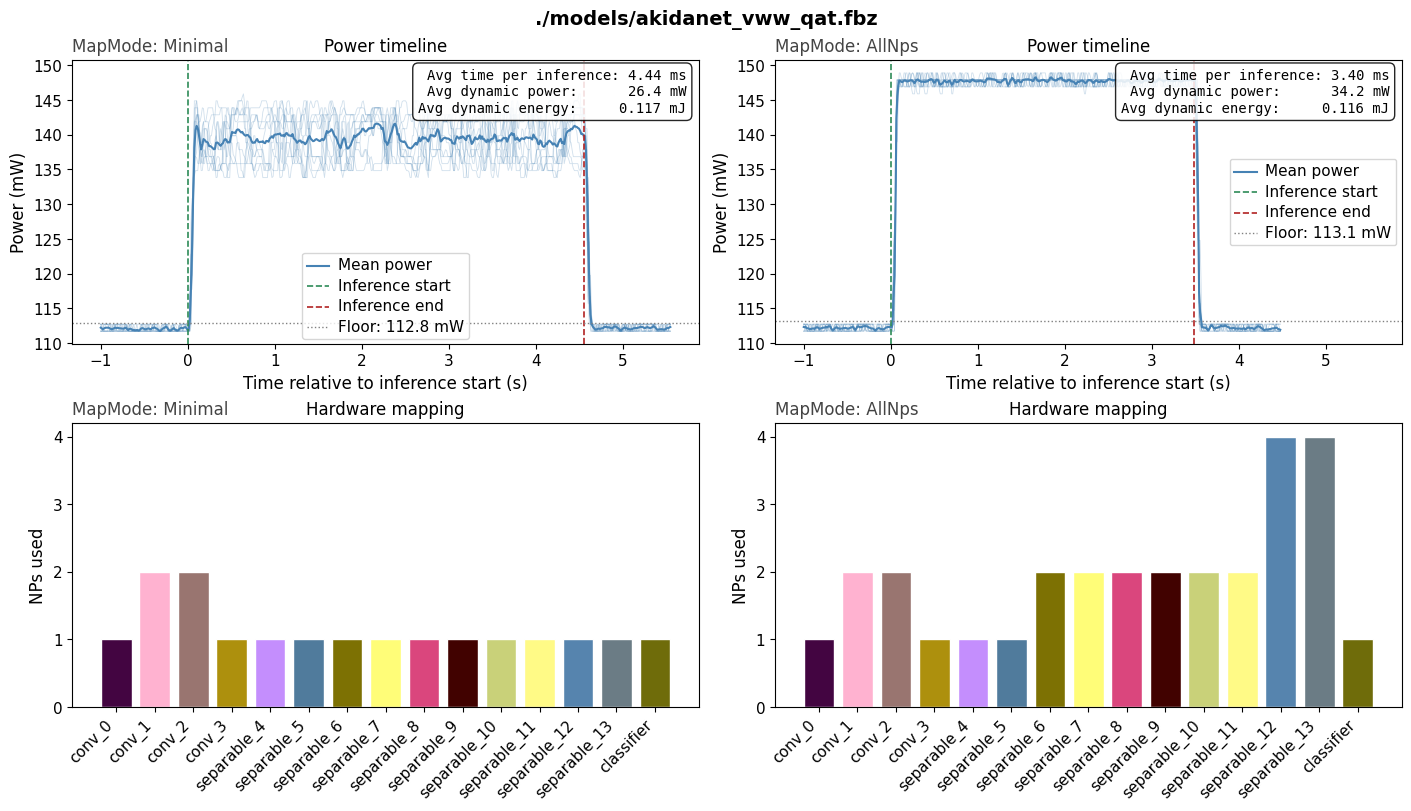

In [19]:
if device is not None:
    plot_full_model_results(full_results, akida_model, device,
                            model_name=akida_model_path,
                            savepath='benchmark_results_full.png')

### Per-Layer Benchmark

Full-model timing tells us the total cost but not where time is spent.
`per_layer_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
reconstructs latency layer by layer by running cumulative sub-models and
differencing the results.

Because Akida processes events (non-zero activations), a layer's cost is
proportional to its *input* sparsity: a layer receiving 90% sparse inputs has
far fewer events to process than one receiving 10% sparse inputs. The per-layer
timing and the sparsity values computed above are therefore naturally correlated —
low-sparsity layers are typically the latency bottlenecks.

In [20]:
from brainchip_utils.hardware_utils import per_layer_benchmark
from brainchip_utils.plot_utils import plot_per_layer_results

if device is not None:
    # Map without hw_only so akida_model.sequences is populated for the plot
    akida_model.map(device, mode=akida.MapMode.Minimal)

    print(f'Running per-layer benchmark ({len(samples)} samples)...')
    per_layer_results = per_layer_benchmark(akida_model, device, samples)

Running per-layer benchmark (1024 samples)...

Layer            Latency (ms)       Clocks
----------------------------------
conv_0                 0.1860
conv_1                 0.2064
conv_2                 0.4963
conv_3                 0.3973
separable_4            0.7378
separable_5            0.4666
separable_6            0.6151
separable_7            0.3132
separable_8            0.1952
separable_9            0.0980
separable_10           0.0600
separable_11           0.0708
separable_12           0.1039
separable_13           0.3921
classifier             0.0202
----------------------------------
Total                  4.3590


The plot stacks three panels: per-layer latency, input sparsity per layer, and
the hardware mapping. The inverse relationship between sparsity and latency is
the direct signature of the event-driven compute model: dense activations
generate more events, and more events mean more work for the hardware.

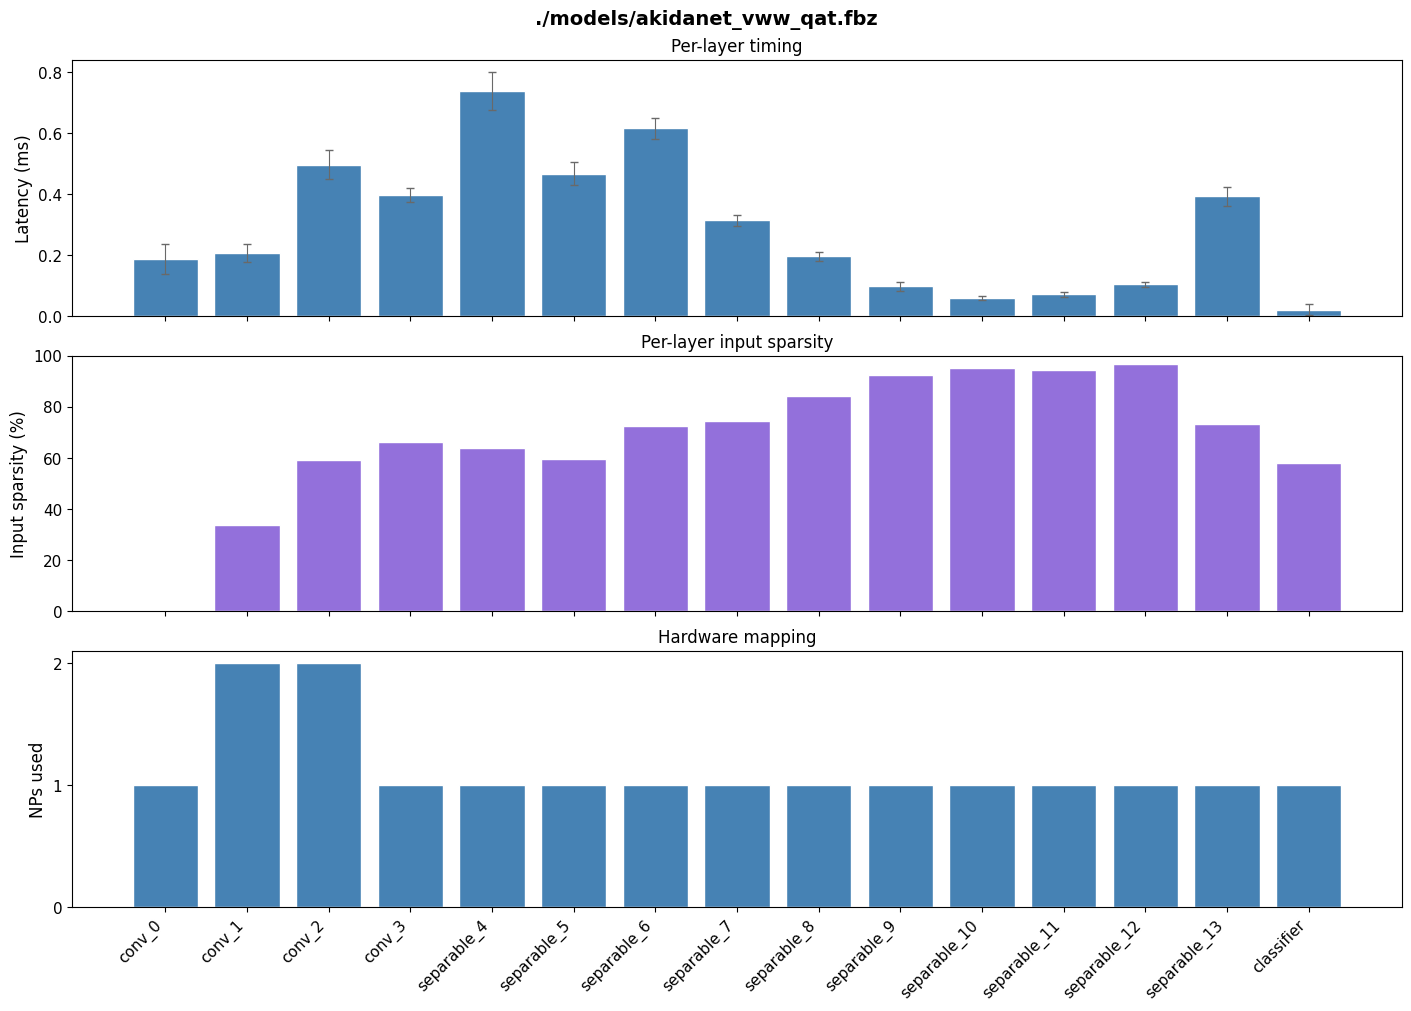

In [21]:
if device is not None:
    plot_per_layer_results(per_layer_results, akida_model, sparsity_dict,
                           model_name=akida_model_path,
                           savepath='benchmark_results_layers.png')

## Summary


In [22]:
print(f"Float: {float_accuracy:.4f}")
print(f"QAT:   {qat_accuracy:.4f}")
print(f"Akida: {akida_accuracy:.4f}")

Float: 0.8694
QAT:   0.8424
Akida: 0.8452
